# 🐍 Python for SQL Analysts — Weekend Starter
## Your First Jupyter Notebook

**Time:** ~1.5 hours  
**Goal:** Learn Python basics through SQL concepts you already know  

Every section shows you the **SQL you'd write** → then the **Python equivalent**.  
Run each cell with `Shift + Enter`.

---

## Part 1: Variables & Data Types (~15 min)
**SQL analogy:** `SELECT 42 AS answer, 'hello' AS greeting`

In [ ]:
# In SQL: SELECT 42 AS answer
# In Python:
answer = 42
print(answer)

In [1]:
# Variables can hold different types of data
name = "Analyst"          # text (string) — like VARCHAR
age = 30                   # whole number (integer) — like INT
salary = 75000.50          # decimal number (float) — like DECIMAL
is_active = True           # boolean — like BOOLEAN

print(f"Name: {name}, Age: {age}, Salary: ${salary:,.2f}, Active: {is_active}")
print(f"Types: {type(name).__name__}, {type(age).__name__}, {type(salary).__name__}, {type(is_active).__name__}")

Name: Analyst, Age: 30, Salary: $75,000.50, Active: True
Types: str, int, float, bool


In [2]:
# Basic math — same operators as SQL
revenue = 150000
costs = 95000
profit = revenue - costs
margin = (profit / revenue) * 100

print(f"Revenue: ${revenue:,}")
print(f"Profit: ${profit:,}")
print(f"Margin: {margin:.1f}%")

Revenue: $150,000
Profit: $55,000
Margin: 36.7%


### ✏️ YOUR TURN — Exercise 1
Create variables for a product: `product_name`, `price`, `quantity`, and `discount_pct`.  
Then calculate and print the total revenue after discount.

In [3]:
# Exercise 1: Fill in below
product_name = 'Iphone 16 Pro'
price = 999
quantity = 10
discount_pct = 5

total_before = price * quantity
discount_amount = total_before * (discount_pct / 100)
total_after = total_before - discount_amount

print(f"{product_name}: ${total_after:,.2f} after {discount_pct}% discount")

Iphone 16 Pro: $9,490.50 after 5% discount


---
## Part 2: Lists & Dictionaries (~15 min)
**SQL analogy:** Lists = result sets. Dictionaries = lookup tables.

In [1]:
# Lists = ordered collections (like a column of results)
# SQL: SELECT region FROM sales
regions = ["North", "South", "East", "West"]
revenues = [50000, 42000, 68000, 55000]

print(f"All regions: {regions}")
print(f"First region: {regions[0]}")     # indexing starts at 0!
print(f"Last region: {regions[-1]}")      # -1 = last item
print(f"Total revenue: ${sum(revenues):,}")
print(f"Number of regions: {len(regions)}")

All regions: ['North', 'South', 'East', 'West']
First region: North
Last region: West
Total revenue: $215,000
Number of regions: 4


In [2]:
# Dictionaries = key-value pairs (like a lookup table / VLOOKUP)
# SQL: think of a small reference table you JOIN to

region_manager = {
    "North": "Alice",
    "South": "Bob",
    "East": "Charlie",
    "West": "Diana"
}

# Look up a value — like a WHERE on your reference table
print(f"North manager: {region_manager['North']}")
print(f"All managers: {list(region_manager.values())}")

North manager: Alice
All managers: ['Alice', 'Bob', 'Charlie', 'Diana']


In [3]:
# Combine them — list of dictionaries = a result set with multiple columns
# SQL: SELECT * FROM employees LIMIT 3

employees = [
    {"name": "Alice",   "dept": "Sales",     "salary": 75000},
    {"name": "Bob",     "dept": "Marketing",  "salary": 68000},
    {"name": "Charlie", "dept": "Sales",     "salary": 82000},
]

# Access like: table[row][column]
print(f"First employee: {employees[0]['name']}")
print(f"Bob's salary: ${employees[1]['salary']:,}")

First employee: Alice
Bob's salary: $68,000


---
## Part 3: If/Else & Loops (~15 min)
**SQL analogy:** `CASE WHEN` and cursor-style row processing

In [4]:
# IF/ELSE = CASE WHEN in SQL
#
# SQL:  CASE WHEN revenue > 60000 THEN 'High'
#             WHEN revenue > 45000 THEN 'Medium'
#             ELSE 'Low' END AS tier

revenue = 55000

if revenue > 60000:
    tier = "High"
elif revenue > 45000:
    tier = "Medium"
else:
    tier = "Low"

print(f"Revenue ${revenue:,} → Tier: {tier}")

Revenue $55,000 → Tier: Medium


In [5]:
# FOR LOOP = processing each row in a result set
#
# SQL: You'd do this with a GROUP BY or window function
# Python: You can loop through and process each item

revenues = [50000, 42000, 68000, 55000, 31000, 72000]

for rev in revenues:
    if rev > 60000:
        tier = "🟢 High"
    elif rev > 45000:
        tier = "🟡 Medium"
    else:
        tier = "🔴 Low"
    print(f"  ${rev:>8,}  →  {tier}")

  $  50,000  →  🟡 Medium
  $  42,000  →  🔴 Low
  $  68,000  →  🟢 High
  $  55,000  →  🟡 Medium
  $  31,000  →  🔴 Low
  $  72,000  →  🟢 High


In [6]:
# FUNCTIONS = reusable CASE WHEN blocks you define once
#
# SQL: Creating a stored function like CREATE FUNCTION classify_revenue(...)

def classify_revenue(amount):
    """Classify revenue into tiers — like a reusable CASE WHEN."""
    if amount > 60000:
        return "High"
    elif amount > 45000:
        return "Medium"
    else:
        return "Low"

# Now use it anywhere — just like calling a SQL function
print(classify_revenue(72000))   # High
print(classify_revenue(38000))   # Low

# Apply it to every item in a list
tiers = [classify_revenue(r) for r in revenues]
print(f"\nAll tiers: {tiers}")

High
Low

All tiers: ['Medium', 'Low', 'High', 'Medium', 'Low', 'High']


### ✏️ YOUR TURN — Exercise 2
Write a function called `grade_performance` that takes a score (0–100) and returns:  
- `"Exceeds"` if score >= 90  
- `"Meets"` if score >= 70  
- `"Below"` if score < 70  

Then test it with scores: 95, 72, 58, 88

In [7]:
# Exercise 2: Write your function below
def grade_performance(score):
    "Classify the grades"
    if score >= 90:
        return "Exceeds"
    elif score < 90 and score >= 70:
        return "Meets"
    else:
        return "Exceeds"

# Test it
test_scores = [95, 72, 58, 88]
for s in test_scores:
    print(f"  Score {s} → {grade_performance(s)}")

  Score 95 → Exceeds
  Score 72 → Meets
  Score 58 → Exceeds
  Score 88 → Meets


---
## Part 4: Pandas — SQL in Python (~30 min)
**This is where it gets exciting. Pandas will feel like home.**

In [9]:
import pandas as pd

# Create a DataFrame — think of it as a SQL table in memory
sales_data = {
    "order_id":    [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    "customer":    ["Acme", "Beta", "Acme", "Gamma", "Beta", "Delta", "Acme", "Gamma", "Delta", "Beta"],
    "region":      ["North", "South", "North", "East", "South", "West", "North", "East", "West", "South"],
    "product":     ["Widget", "Gadget", "Widget", "Widget", "Gadget", "Gizmo", "Gizmo", "Widget", "Gadget", "Widget"],
    "quantity":    [10, 5, 8, 12, 3, 15, 7, 9, 6, 11],
    "unit_price":  [25.0, 45.0, 25.0, 25.0, 45.0, 60.0, 60.0, 25.0, 45.0, 25.0],
    "order_date":  ["2024-01-05", "2024-01-08", "2024-01-12", "2024-01-15", "2024-01-18",
                    "2024-01-22", "2024-01-25", "2024-02-01", "2024-02-05", "2024-02-10"]
}

df = pd.DataFrame(sales_data)
df["order_date"] = pd.to_datetime(df["order_date"])
df["revenue"] = df["quantity"] * df["unit_price"]

print("✅ Sales table created! Here's what it looks like:")
df

✅ Sales table created! Here's what it looks like:


,order_id,customer,region,product,quantity,unit_price,order_date,revenue
0,101,Acme,North,Widget,10,25.0,2024-01-05,250.0
1,102,Beta,South,Gadget,5,45.0,2024-01-08,225.0
2,103,Acme,North,Widget,8,25.0,2024-01-12,200.0
3,104,Gamma,East,Widget,12,25.0,2024-01-15,300.0
4,105,Beta,South,Gadget,3,45.0,2024-01-18,135.0
5,106,Delta,West,Gizmo,15,60.0,2024-01-22,900.0
6,107,Acme,North,Gizmo,7,60.0,2024-01-25,420.0
7,108,Gamma,East,Widget,9,25.0,2024-02-01,225.0
8,109,Delta,West,Gadget,6,45.0,2024-02-05,270.0
9,110,Beta,South,Widget,11,25.0,2024-02-10,275.0


In [10]:
# ━━━ SELECT * FROM sales LIMIT 5 ━━━
df.head(5)

,order_id,customer,region,product,quantity,unit_price,order_date,revenue
0,101,Acme,North,Widget,10,25.0,2024-01-05,250.0
1,102,Beta,South,Gadget,5,45.0,2024-01-08,225.0
2,103,Acme,North,Widget,8,25.0,2024-01-12,200.0
3,104,Gamma,East,Widget,12,25.0,2024-01-15,300.0
4,105,Beta,South,Gadget,3,45.0,2024-01-18,135.0


In [11]:
# ━━━ SELECT customer, revenue FROM sales ━━━
df[["customer", "revenue"]]

,customer,revenue
0,Acme,250.0
1,Beta,225.0
2,Acme,200.0
3,Gamma,300.0
4,Beta,135.0
5,Delta,900.0
6,Acme,420.0
7,Gamma,225.0
8,Delta,270.0
9,Beta,275.0


In [12]:
# ━━━ SELECT * FROM sales WHERE region = 'North' ━━━
df[df["region"] == "North"]

,order_id,customer,region,product,quantity,unit_price,order_date,revenue
0,101,Acme,North,Widget,10,25.0,2024-01-05,250.0
2,103,Acme,North,Widget,8,25.0,2024-01-12,200.0
6,107,Acme,North,Gizmo,7,60.0,2024-01-25,420.0


In [13]:
# ━━━ SELECT * FROM sales WHERE revenue > 300 AND region = 'South' ━━━
df[(df["revenue"] > 300) & (df["region"] == "South")]

,order_id,customer,region,product,quantity,unit_price,order_date,revenue


In [14]:
# ━━━ SELECT * FROM sales ORDER BY revenue DESC ━━━
df.sort_values("revenue", ascending=False)

,order_id,customer,region,product,quantity,unit_price,order_date,revenue
5,106,Delta,West,Gizmo,15,60.0,2024-01-22,900.0
6,107,Acme,North,Gizmo,7,60.0,2024-01-25,420.0
3,104,Gamma,East,Widget,12,25.0,2024-01-15,300.0
9,110,Beta,South,Widget,11,25.0,2024-02-10,275.0
8,109,Delta,West,Gadget,6,45.0,2024-02-05,270.0
0,101,Acme,North,Widget,10,25.0,2024-01-05,250.0
1,102,Beta,South,Gadget,5,45.0,2024-01-08,225.0
7,108,Gamma,East,Widget,9,25.0,2024-02-01,225.0
2,103,Acme,North,Widget,8,25.0,2024-01-12,200.0
4,105,Beta,South,Gadget,3,45.0,2024-01-18,135.0


In [15]:
# ━━━ SELECT customer, SUM(revenue) as total_rev
#      FROM sales
#      GROUP BY customer
#      ORDER BY total_rev DESC ━━━

df.groupby("customer")["revenue"].sum().sort_values(ascending=False)

customer
Delta    1170.0
Acme      870.0
Beta      635.0
Gamma     525.0
Name: revenue, dtype: float64

In [16]:
# ━━━ SELECT region,
#             COUNT(*) as num_orders,
#             SUM(revenue) as total_rev,
#             AVG(revenue) as avg_rev
#      FROM sales
#      GROUP BY region ━━━

df.groupby("region").agg(
    num_orders=("order_id", "count"),
    total_rev=("revenue", "sum"),
    avg_rev=("revenue", "mean")
).round(2)

,num_orders,total_rev,avg_rev
region,,,
East,2,525.0,262.50
North,3,870.0,290.00
South,3,635.0,211.67
West,2,1170.0,585.00


In [17]:
# ━━━ SELECT region, product, SUM(revenue)
#      FROM sales
#      GROUP BY region, product  (as a pivot table) ━━━

pd.pivot_table(df, values="revenue", index="region", columns="product", aggfunc="sum", fill_value=0)

product,Gadget,Gizmo,Widget
region,,,
East,0.0,0.0,525.0
North,0.0,420.0,450.0
South,360.0,0.0,275.0
West,270.0,900.0,0.0


In [18]:
# ━━━ SELECT DISTINCT customer FROM sales ━━━
df["customer"].unique()

<StringArray>
['Acme', 'Beta', 'Gamma', 'Delta']
Length: 4, dtype: str

In [19]:
# ━━━ SELECT customer, COUNT(*) FROM sales
#      GROUP BY customer
#      HAVING COUNT(*) > 2 ━━━

counts = df.groupby("customer")["order_id"].count()
counts[counts > 2]

customer
Acme    3
Beta    3
Name: order_id, dtype: int64

### ✏️ YOUR TURN — Exercise 3 (The Fun One)
Using the `df` DataFrame above, write Pandas code for these SQL queries:

1. `SELECT * FROM sales WHERE product = 'Widget'`
2. `SELECT product, SUM(quantity) FROM sales GROUP BY product`
3. `SELECT * FROM sales WHERE revenue > 250 ORDER BY order_date`

In [21]:
# Exercise 3.1: All Widget orders
df[df["product"] == "Widget"]

,order_id,customer,region,product,quantity,unit_price,order_date,revenue
0,101,Acme,North,Widget,10,25.0,2024-01-05,250.0
2,103,Acme,North,Widget,8,25.0,2024-01-12,200.0
3,104,Gamma,East,Widget,12,25.0,2024-01-15,300.0
7,108,Gamma,East,Widget,9,25.0,2024-02-01,225.0
9,110,Beta,South,Widget,11,25.0,2024-02-10,275.0


In [24]:
# Exercise 3.2: Total quantity by product
df.groupby("product")["quantity"].sum()

product
Gadget    14
Gizmo     22
Widget    50
Name: quantity, dtype: int64

In [26]:
# Exercise 3.3: Orders over $250, sorted by date
df[df["revenue"] > 250].sort_values("order_date")

,order_id,customer,region,product,quantity,unit_price,order_date,revenue
3,104,Gamma,East,Widget,12,25.0,2024-01-15,300.0
5,106,Delta,West,Gizmo,15,60.0,2024-01-22,900.0
6,107,Acme,North,Gizmo,7,60.0,2024-01-25,420.0
8,109,Delta,West,Gadget,6,45.0,2024-02-05,270.0
9,110,Beta,South,Widget,11,25.0,2024-02-10,275.0


---
## Part 5: Your First Chart (~15 min)
**SQL can't do this. Python can.**

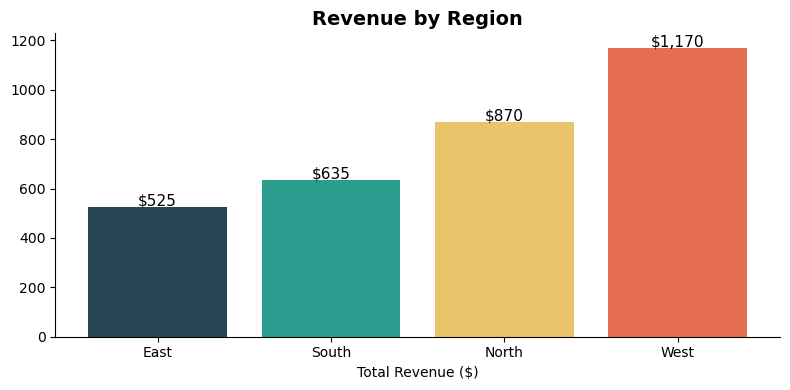

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Revenue by region — bar chart
region_rev = df.groupby("region")["revenue"].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(region_rev.index, region_rev.values, color=["#264653", "#2a9d8f", "#e9c46a", "#e76f51"])
ax.set_xlabel("Total Revenue ($)")
ax.set_title("Revenue by Region", fontweight="bold", fontsize=14)

# Add value labels on bars
for bar, val in zip(bars, region_rev.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"${val:,.0f}", ha="center", fontsize=11)
    
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

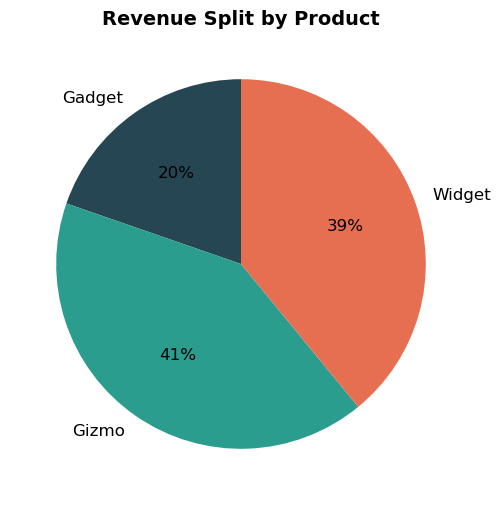

In [32]:
# Revenue by product — pie chart (just to show what's possible)
product_rev = df.groupby("product")["revenue"].sum()

fig, ax = plt.subplots(figsize=(6, 6))
colors = ["#264653", "#2a9d8f", "#e76f51"]
ax.pie(product_rev, labels=product_rev.index, autopct="%1.0f%%",
       colors=colors, startangle=90, textprops={"fontsize": 12})
ax.set_title("Revenue Split by Product", fontweight="bold", fontsize=14)
plt.show()

---
## 🎉 Congrats — You Just Wrote Python!

### Quick Reference Card: SQL → Pandas

| SQL | Pandas |
|-----|--------|
| `SELECT *` | `df` |
| `SELECT col1, col2` | `df[["col1", "col2"]]` |
| `WHERE col = 'x'` | `df[df["col"] == "x"]` |
| `WHERE col > 5 AND col2 = 'x'` | `df[(df["col"] > 5) & (df["col2"] == "x")]` |
| `ORDER BY col DESC` | `df.sort_values("col", ascending=False)` |
| `GROUP BY col` | `df.groupby("col")` |
| `COUNT(*)` | `.count()` |
| `SUM(col)` | `.sum()` |
| `AVG(col)` | `.mean()` |
| `DISTINCT` | `.unique()` or `.nunique()` |
| `HAVING` | filter after groupby |
| `LIMIT 5` | `.head(5)` |
| `JOIN` | `pd.merge(df1, df2, on="key")` |

### Next Steps
1. ✅ Push this notebook to GitHub (your first commit!)
2. 📊 Try loading a real CSV from work: `df = pd.read_csv("your_file.csv")`
3. 🔁 Come back next week for Weeks 3–4: Data Structures & File I/O